In [ ]:
import pandas as pd

df = pd.read_csv('aice_multiclass_practice.csv')

# 데이터 상위 5개 
df.head()

,customer_id,signup_date,age,monthly_spend,visits_per_month,support_calls,membership_type,region,device,satisfaction_score,target_segment
0,CUST0001,2022-03-07,37.0,120.49,10,3,VIP,Seoul,iOS,3.3,2
1,CUST0002,2023-07-24,47.0,137.19,9,2,Silver,Busan,Android,3.8,3
2,CUST0003,2024-02-18,39.0,124.15,13,0,VIP,Daegu,Android,3.1,3
3,CUST0004,2023-08-24,58.0,190.90,3,0,VIP,Incheon,Android,3.3,3
4,CUST0005,2023-04-22,46.0,62.95,15,0,Basic,Daegu,Web,3.3,1


In [ ]:
# 컬럼별 자료형 및 결측치 여부
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         600 non-null    str    
 1   signup_date         600 non-null    str    
 2   age                 576 non-null    float64
 3   monthly_spend       582 non-null    float64
 4   visits_per_month    600 non-null    int64  
 5   support_calls       600 non-null    int64  
 6   membership_type     580 non-null    str    
 7   region              600 non-null    str    
 8   device              600 non-null    str    
 9   satisfaction_score  600 non-null    float64
 10  target_segment      600 non-null    int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 51.7 KB


In [3]:
# 각 컬럼의 결측치 개수
df.isnull().sum()

customer_id            0
signup_date            0
age                   24
monthly_spend         18
visits_per_month       0
support_calls          0
membership_type       20
region                 0
device                 0
satisfaction_score     0
target_segment         0
dtype: int64

In [4]:
# customer_id = 모델 학습에 불필요
df = df.drop(columns=['customer_id'])

In [7]:
# signup_date  컬럼 -> 날짜 자료형 / signup_year, signup_month / 원본 삭제
df['signup_date'] = pd.to_datetime(df['signup_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   signup_date         600 non-null    datetime64[us]
 1   age                 576 non-null    float64       
 2   monthly_spend       582 non-null    float64       
 3   visits_per_month    600 non-null    int64         
 4   support_calls       600 non-null    int64         
 5   membership_type     580 non-null    str           
 6   region              600 non-null    str           
 7   device              600 non-null    str           
 8   satisfaction_score  600 non-null    float64       
 9   target_segment      600 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(3), str(3)
memory usage: 47.0 KB


In [13]:
df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month

df = df.drop(columns=['signup_date'])
df.head()

,age,monthly_spend,visits_per_month,support_calls,membership_type,region,device,satisfaction_score,target_segment,signup_year,signup_month
0,37.0,120.49,10,3,VIP,Seoul,iOS,3.3,2,2022,3
1,47.0,137.19,9,2,Silver,Busan,Android,3.8,3,2023,7
2,39.0,124.15,13,0,VIP,Daegu,Android,3.1,3,2024,2
3,58.0,190.90,3,0,VIP,Incheon,Android,3.3,3,2023,8
4,46.0,62.95,15,0,Basic,Daegu,Web,3.3,1,2023,4


In [14]:
# 결측치 컬럼 처리
df['age'] = df['age'].fillna(df['age'].median())
df['monthly_spend'] = df['monthly_spend'].fillna(df['monthly_spend'].median())
df['membership_type'] = df['membership_type'].fillna(df['membership_type'].mode()[0])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 600 non-null    float64
 1   monthly_spend       600 non-null    float64
 2   visits_per_month    600 non-null    int64  
 3   support_calls       600 non-null    int64  
 4   membership_type     600 non-null    str    
 5   region              600 non-null    str    
 6   device              600 non-null    str    
 7   satisfaction_score  600 non-null    float64
 8   target_segment      600 non-null    int64  
 9   signup_year         600 non-null    int32  
 10  signup_month        600 non-null    int32  
dtypes: float64(3), int32(2), int64(3), str(3)
memory usage: 47.0 KB


In [16]:
# 범주형 one hot encoding
print(df['membership_type'].value_counts())
print(df['region'].value_counts())
print(df['device'].value_counts())

membership_type
Basic     233
Silver    162
Gold      142
VIP        63
Name: count, dtype: int64
region
Incheon    168
Seoul      153
Busan      141
Daegu      138
Name: count, dtype: int64
device
Android    276
iOS        217
Web        107
Name: count, dtype: int64


In [17]:
df = pd.get_dummies(df, columns=['membership_type', 'region', 'device'], dtype=int)
df.head()

,age,monthly_spend,visits_per_month,support_calls,satisfaction_score,target_segment,signup_year,signup_month,membership_type_Basic,membership_type_Gold,membership_type_Silver,membership_type_VIP,region_Busan,region_Daegu,region_Incheon,region_Seoul,device_Android,device_Web,device_iOS
0,37.0,120.49,10,3,3.3,2,2022,3,0,0,0,1,0,0,0,1,0,0,1
1,47.0,137.19,9,2,3.8,3,2023,7,0,0,1,0,1,0,0,0,1,0,0
2,39.0,124.15,13,0,3.1,3,2024,2,0,0,0,1,0,1,0,0,1,0,0
3,58.0,190.90,3,0,3.3,3,2023,8,0,0,0,1,0,0,1,0,1,0,0
4,46.0,62.95,15,0,3.3,1,2023,4,1,0,0,0,0,1,0,0,0,1,0


In [ ]:
# x, y 분리 
x = df.drop(columns=['target_segment'])
y = df['target_segment']

In [34]:
# 고유 클래스 개수
import numpy as np

print('클래스 개수 : ', len(np.unique(y)))
print('고유값 : ', np.unique(y))

클래스 개수 :  4
고유값 :  [0 1 2 3]


In [30]:
# 학습용 / 테스트용 데이터 분리
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

In [ ]:
# StandardScaler 데이터 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

num_classes = len(np.unique(y_train))

model = Sequential([
  # shape=안에 있다고 해서 .shape를 안쓰면 안됨
  Input(shape=(x_train_scaled.shape[1],)),
  Dense(64, activation='relu'),
  Dropout(0.2),
  Dense(32, activation='relu'),
  Dense(num_classes, activation='softmax')
])

In [43]:
# 모델 컴파일
# EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
  monitor='val_loss',
  patience=5,
  restore_best_weights=True
)

model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [44]:
# 모델 학습
history = model.fit(
  x_train_scaled,
  y_train,
  epochs=50,
  batch_size=32,
  validation_split=0.2,
  callbacks=[early_stop]
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1901 - loss: 1.5363 - val_accuracy: 0.2604 - val_loss: 1.3975
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2943 - loss: 1.3739 - val_accuracy: 0.3021 - val_loss: 1.3079
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3984 - loss: 1.2644 - val_accuracy: 0.3750 - val_loss: 1.2507
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4531 - loss: 1.2058 - val_accuracy: 0.4375 - val_loss: 1.1982
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4740 - loss: 1.1641 - val_accuracy: 0.5000 - val_loss: 1.1544
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4766 - loss: 1.1236 - val_accuracy: 0.5521 - val_loss: 1.1089
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5391 - loss: 1.0646 - val_accuracy: 0.5625 - val_loss: 1.0666
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5573 - loss: 1.0243 - val_accuracy: 0.5938 - val_loss

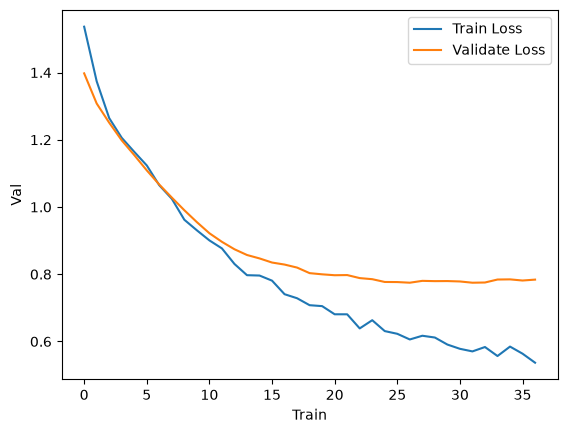

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.show()

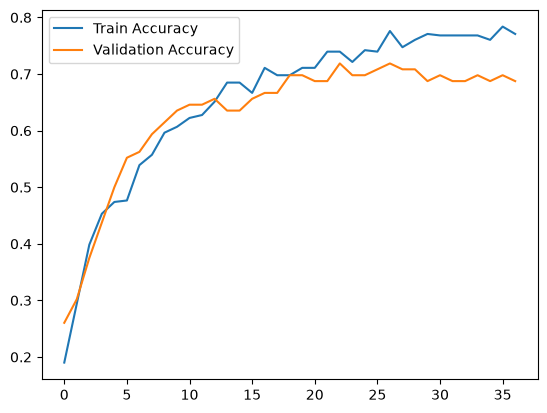

In [50]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.show()

In [51]:
test_loss, test_accuracy = model.evaluate(
  x_test_scaled,
  y_test
)

print("loss : ", test_loss)
print("accuracy : ", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6083 - loss: 0.8969  
loss :  0.8969463109970093
accuracy :  0.6083333492279053
